<a href="https://colab.research.google.com/github/LucaR45/Cnn-Rock-Paper-Scissors/blob/main/cnn_versione_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Exploration and Preprocessing

In [ ]:
import os
# Insert your kaggle data
os.environ['KAGGLE_USERNAME'] = "xxxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxxx"

In [ ]:
# Download a dataset from Kaggle
!kaggle datasets download -d drgfreeman/rockpaperscissors --unzip

Dataset URL: https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors
License(s): CC-BY-SA-4.0
 87% 266M/306M [00:00<00:00, 514MB/s]
100% 306M/306M [00:00<00:00, 535MB/s]


In [ ]:
print("Rock images :" +str(len(os.listdir('/content/rock'))))
print("Paper images :" +str(len(os.listdir('/content/paper'))))
print("Scissors images :" +str(len(os.listdir('/content/scissors'))))

Rock images :726
Paper images :712
Scissors images :750


In [ ]:
rock_path = '/content/rock'
paper_path = '/content/paper'
scissors_path = '/content/scissors'

rock_images = os.listdir(rock_path)
paper_images = os.listdir(paper_path)
scissors_images = os.listdir(scissors_path)

print(len(rock_images))
print(len(paper_images))
print(len(scissors_images))

726
712
750


Dataframe


In [ ]:
path = '/content/rps-cv-images'

In [ ]:
# collects file paths for each image and assigns a label
paths = []
labels = []
base_dir = "/content/rps-cv-images"
for item_name in os.listdir(base_dir):
  item_path = os.path.join(base_dir, item_name)
  if os.path.isdir(item_path):
    for path in os.listdir(item_path):
      if item_name == 'paper':
        labels.append("paper")
      elif item_name == 'scissors':
        labels.append("scissors")
      else:
        labels.append("rock")
      paths.append(os.path.join(item_path, path))

In [ ]:
import pandas as pd

df = pd.DataFrame()
df['paths'] = paths
df['label'] = labels

df.sample(5, random_state=56)

,paths,label
1037,/content/rps-cv-images/rock/zdNuxse3BvJK3s6Q.png,rock
243,/content/rps-cv-images/paper/hH7jcOkAiHqNDWcy.png,paper
583,/content/rps-cv-images/paper/aOiWbMZF8BhxwLTs.png,paper
1777,/content/rps-cv-images/scissors/hJuytZrZ7fR1CW...,scissors
610,/content/rps-cv-images/paper/8cUuoeM7qSsAGoOv.png,paper


Image


In [ ]:
Height = 96
Width = 96
Size = (Width, Height)
Channels = 3

Generator
Splitting data and generator

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train_temp, df_test = train_test_split(df, test_size=0.1, random_state=90)
df_train, df_validation = train_test_split(df_train_temp, test_size=0.111, random_state=90)

In [ ]:
df_test

,paths,label
430,/content/rps-cv-images/paper/yYiQN5jZvkGqr6C5.png,paper
1938,/content/rps-cv-images/scissors/hP1nFePk6ao9xK...,scissors
631,/content/rps-cv-images/paper/mWtDBJ2pprz96x22.png,paper
1973,/content/rps-cv-images/scissors/fXrAew7llUJLK8...,scissors
2156,/content/rps-cv-images/scissors/yAuOKZfd9CyDMY...,scissors
...,...,...
1046,/content/rps-cv-images/rock/7xID6kq32pdkEBIe.png,rock
885,/content/rps-cv-images/rock/y0ZTIzS3rpKagERb.png,rock
335,/content/rps-cv-images/paper/ocaU2HmemX7rmjm0.png,paper
1061,/content/rps-cv-images/rock/Dt2vWLtAYm3XeQpx.png,rock


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_generator = ImageDataGenerator(rescale=1./255)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_generator = ImageDataGenerator(rescale=1./255)

test_gen = data_generator.flow_from_dataframe(dataframe = df_test,
                                                        directory=None,
                                                        x_col="paths", y_col="label",
                                                        batch_size=64, seed = 55,
                                                        shuffle=True, class_mode="categorical",
                                                        target_size=Size)
train_gen = data_generator.flow_from_dataframe(dataframe = df_train,
                                                        directory=None,
                                                        x_col="paths", y_col="label",
                                                        batch_size=64, seed = 55,
                                                        shuffle=True, class_mode="categorical",
                                                        target_size=Size)
valid_gen = data_generator.flow_from_dataframe(dataframe = df_validation,
                                                        directory=None,
                                                        x_col="paths", y_col="label",
                                                        batch_size=64, seed = 55,
                                                        shuffle=True, class_mode="categorical",
                                                        target_size=Size)

Found 219 validated image filenames belonging to 3 classes.
Found 1750 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.


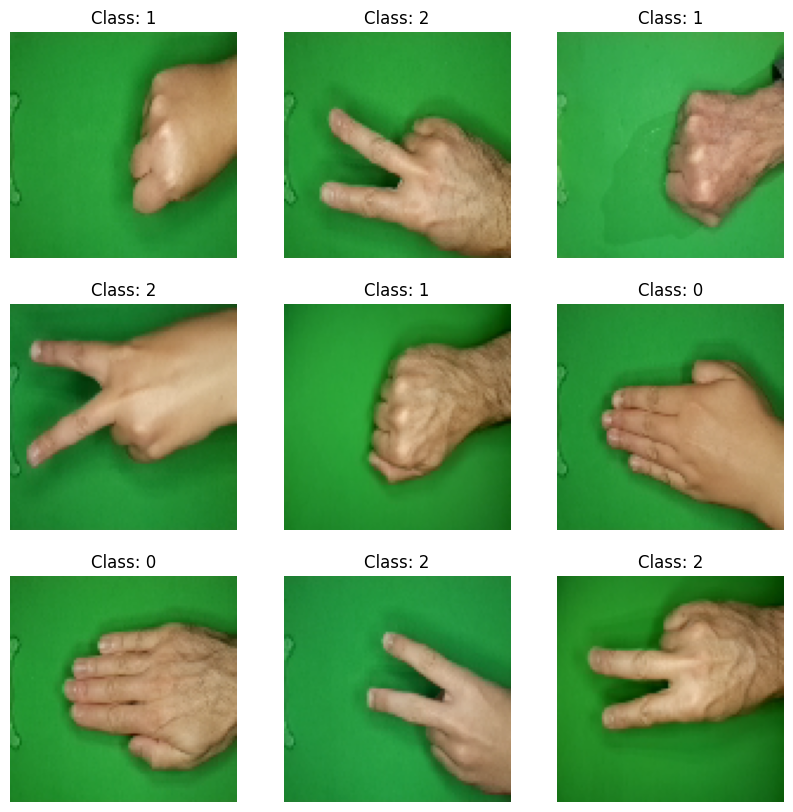

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(train_gen)

# first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {labels[i].argmax()}")
    plt.axis("off")

plt.show()

cnn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [ ]:
def cnn1():
  cnn1 = Sequential()
  cnn1.add(Conv2D(64, (3, 3), activation='relu', input_shape=(Width, Height, Channels)))
  cnn1.add(BatchNormalization())
  cnn1.add(MaxPooling2D((2, 2)))
  cnn1.add(Dropout(0.3,seed=44))

  cnn1.add(Conv2D(64, (3, 3), activation='relu'))
  cnn1.add(MaxPooling2D((2, 2)))
  cnn1.add(Dropout(0.4,seed=44))

  cnn1.add(Flatten())
  cnn1.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
  cnn1.add(Dropout(0.4,seed=44))

  cnn1.add(Dense(3, activation='softmax'))

  cnn1.compile(
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

  return cnn1

In [ ]:
model_to_train = cnn1()
history1 = model_to_train.fit(
    train_gen,
    epochs= 40,
    validation_data=valid_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.3938 - loss: 7.9021 - val_accuracy: 0.3744 - val_loss: 1.5711
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.4537 - loss: 1.4407 - val_accuracy: 0.4110 - val_loss: 1.3384
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.5648 - loss: 1.1129 - val_accuracy: 0.6210 - val_loss: 1.1730
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.5779 - loss: 0.9296 - val_accuracy: 0.3516 - val_loss: 1.1422
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.5963 - loss: 0.7702 - val_accuracy: 0.4703 - val_loss: 1.0918
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.6453 - loss: 0.7155 - val_accuracy: 0.3425 - val_loss: 1.1337
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.7085 - loss: 0.5711 - val_accuracy: 0.4475 - val_loss: 1.0610
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.7514 - loss: 0.5211 - val_accuracy: 0.4475 - val_loss:

Text(0.5, 1.0, 'CNN1')

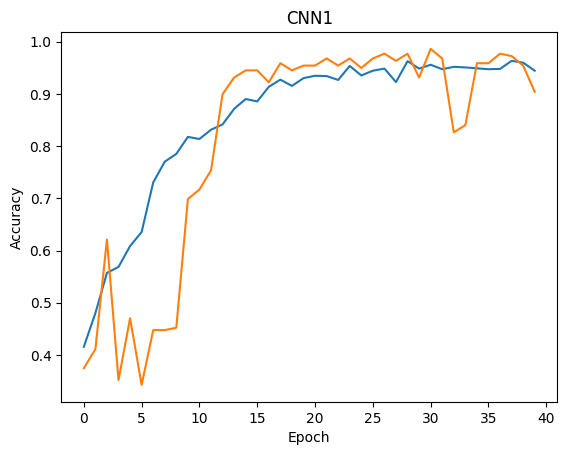

In [ ]:
plt.plot(history1.history['accuracy'], label='training_accuracy')
plt.plot(history1.history['val_accuracy'], label = 'test_accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("CNN1")

In [ ]:
def cnn1_2():
  cnn1_2 = Sequential()
  cnn1_2.add(Conv2D(64, (3, 3), activation='relu', input_shape=(Width, Height, Channels)))
  cnn1_2.add(BatchNormalization())
  cnn1_2.add(MaxPooling2D((2, 2)))
  cnn1_2.add(Dropout(0.3,seed=44))

  cnn1_2.add(Conv2D(64, (3, 3), activation='relu'))
  cnn1_2.add(MaxPooling2D((2, 2)))
  cnn1_2.add(Dropout(0.4,seed=44))

  cnn1_2.add(Flatten())
  cnn1_2.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
  cnn1_2.add(Dropout(0.4,seed=44))

  cnn1_2.add(Dense(3, activation='softmax'))
  custom_adam = Adam(learning_rate=0.0003)

  cnn1_2.compile(
        loss='categorical_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

  return cnn1_2

In [ ]:
model_to_train = cnn1_2()
history1_2 = model_to_train.fit(
    train_gen,
    epochs= 30,
    validation_data=valid_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.4206 - loss: 2.9989 - val_accuracy: 0.5205 - val_loss: 1.6923
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.5756 - loss: 1.4054 - val_accuracy: 0.6027 - val_loss: 1.6240
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.6273 - loss: 1.2296 - val_accuracy: 0.5023 - val_loss: 1.5725
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.7701 - loss: 1.0782 - val_accuracy: 0.8356 - val_loss: 1.4745
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.7807 - loss: 1.0016 - val_accuracy: 0.7626 - val_loss: 1.4470
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.8165 - loss: 0.8773 - val_accuracy: 0.8128 - val_loss: 1.3927
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8070 - loss: 0.8326 - val_accuracy: 0.7443 - val_loss: 1.3387
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.8609 - loss: 0.7349 - val_accuracy: 0.8174 - val_loss:

Text(0.5, 1.0, 'CNN1_2')

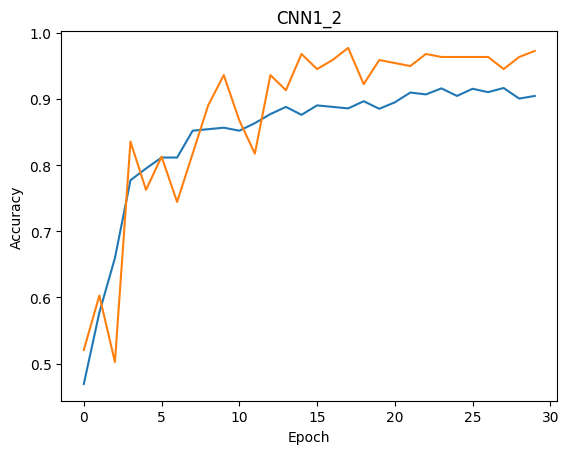

In [ ]:
plt.plot(history1_2.history['accuracy'], label='training_accuracy')
plt.plot(history1_2.history['val_accuracy'], label = 'test_accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("CNN1_2")


In [ ]:
def cnn1_3():
  cnn1_3 = Sequential()
  cnn1_3.add(Conv2D(64, (3, 3), activation='relu', input_shape=(Width, Height, Channels)))
  cnn1_3.add(BatchNormalization())
  cnn1_3.add(MaxPooling2D((2, 2)))
  cnn1_3.add(Dropout(0.3, seed=44))

  cnn1_3.add(Conv2D(64, (3, 3), activation='relu'))
  cnn1_3.add(MaxPooling2D((2, 2)))
  cnn1_3.add(Dropout(0.4, seed=44))

  cnn1_3.add(Flatten())
  cnn1_3.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
  cnn1_3.add(Dropout(0.4, seed=44))

  cnn1_3.add(Dense(3, activation='softmax'))

  custom_adam = Adam(learning_rate=0.0001)

  cnn1_3.compile(
        loss='categorical_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

  return cnn1_3

In [ ]:
model_to_train = cnn1_3()
history1_3 = model_to_train.fit(
    train_gen,
    epochs= 30,
    validation_data=valid_gen,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.4458 - loss: 1.8590 - val_accuracy: 0.7534 - val_loss: 1.6781
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.7023 - loss: 1.3040 - val_accuracy: 0.8265 - val_loss: 1.6375
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8006 - loss: 1.1335 - val_accuracy: 0.7854 - val_loss: 1.5957
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.8453 - loss: 1.0043 - val_accuracy: 0.8219 - val_loss: 1.5285
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.8673 - loss: 0.9154 - val_accuracy: 0.7808 - val_loss: 1.4915
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.9098 - loss: 0.8293 - val_accuracy: 0.8539 - val_loss: 1.3959
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9127 - loss: 0.7731 - val_accuracy: 0.8402 - val_loss: 1.3368
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9311 - loss: 0.7278 - val_accuracy: 0.8813 - val_loss:

Text(0.5, 1.0, 'CNN1_3')

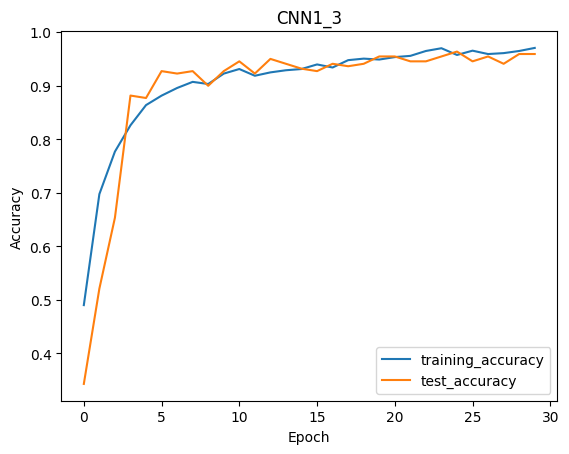

In [ ]:
plt.plot(history1_3.history['accuracy'], label='training_accuracy')
plt.plot(history1_3.history['val_accuracy'], label = 'test_accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title("CNN1_3")


Model 2

In [ ]:
def cnn2():
  cnn2 = Sequential()


  cnn2.add(Conv2D(32, (3, 3), activation='relu', input_shape=(Width, Height, Channels)))
  cnn2.add(BatchNormalization())
  cnn2.add(MaxPooling2D((2, 2)))
  cnn2.add(Dropout(0.3,seed=44))


  cnn2.add(Conv2D(32, (3, 3), activation='relu'))
  cnn2.add(MaxPooling2D((2, 2)))
  cnn2.add(Dropout(0.4,seed=44))

  cnn2.add(Conv2D(32, (3, 3), activation='relu'))
  cnn2.add(MaxPooling2D((2, 2)))
  cnn2.add(Dropout(0.4,seed=44))

  cnn2.add(Flatten())
  cnn2.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
  cnn2.add(Dropout(0.4,seed=44))

  cnn2.add(Dense(3, activation='softmax'))
  custom_adam = Adam(learning_rate=0.0001)

  cnn2.compile(loss='categorical_crossentropy',
               optimizer =custom_adam,
               metrics = ['accuracy'])

  return cnn2

In [ ]:
model_to_train2 = cnn2()
history2 = model_to_train2.fit(
    train_gen,
    epochs= 30,
    validation_data=valid_gen,
    batch_size=64
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3645 - loss: 2.4466 - val_accuracy: 0.5205 - val_loss: 1.7123
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4395 - loss: 1.7530 - val_accuracy: 0.5708 - val_loss: 1.7045
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4622 - loss: 1.6650 - val_accuracy: 0.6986 - val_loss: 1.6928
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5322 - loss: 1.5737 - val_accuracy: 0.6758 - val_loss: 1.6766
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6001 - loss: 1.4969 - val_accuracy: 0.7580 - val_loss: 1.6481
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6705 - loss: 1.3721 - val_accuracy: 0.7580 - val_loss: 1.6116
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6753 - loss: 1.3579 - val_accuracy: 0.7808 - val_loss: 1.5783
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7257 - loss: 1.2637 - val_accuracy: 0.8174 - val_loss:

Text(0.5, 1.0, 'CNN2')

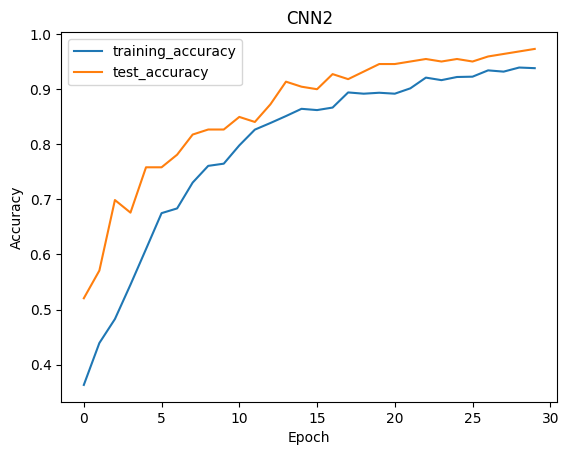

In [ ]:
plt.plot(history2.history['accuracy'], label='training_accuracy')
plt.plot(history2.history['val_accuracy'], label = 'test_accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title("CNN2")

Model 3

In [ ]:
def cnn3():
  cnn3 = Sequential()


  cnn3.add(Conv2D(64, (3, 3), activation='relu', input_shape=(Width, Height, Channels)))
  cnn3.add(BatchNormalization())
  cnn3.add(MaxPooling2D((2, 2)))
  cnn3.add(Dropout(0.3,seed=44))


  cnn3.add(Conv2D(64, (3, 3), activation='relu'))
  cnn3.add(MaxPooling2D((2, 2)))
  cnn3.add(Dropout(0.4,seed=44))

  cnn3.add(Conv2D(64, (3, 3), activation='relu'))
  cnn3.add(MaxPooling2D((2, 2)))
  cnn3.add(Dropout(0.4,seed=44))

  cnn3.add(Flatten())
  cnn3.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
  cnn3.add(Dropout(0.4,seed=44))

  cnn3.add(Dense(3, activation='softmax'))
  custom_adam = Adam(learning_rate=0.0001)

  cnn3.compile(loss='categorical_crossentropy',
               optimizer = custom_adam,
               metrics = ['accuracy'])

  return cnn3

In [ ]:
model_to_train3 = cnn3()
history3 = model_to_train3.fit(
    train_gen,
    epochs= 30,
    validation_data=valid_gen,
    batch_size=64
   )

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.3634 - loss: 2.1522 - val_accuracy: 0.4292 - val_loss: 1.7208
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.4861 - loss: 1.6319 - val_accuracy: 0.5616 - val_loss: 1.7056
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.5700 - loss: 1.4999 - val_accuracy: 0.5571 - val_loss: 1.6774
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.6799 - loss: 1.3702 - val_accuracy: 0.5342 - val_loss: 1.6530
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.7514 - loss: 1.2363 - val_accuracy: 0.6530 - val_loss: 1.6228
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.8039 - loss: 1.1155 - val_accuracy: 0.7443 - val_loss: 1.5775
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.8348 - loss: 1.0398 - val_accuracy: 0.8265 - val_loss: 1.5333
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.8520 - loss: 0.9843 - val_accuracy: 0.7900 - val_loss:

Text(0.5, 1.0, 'CNN3')

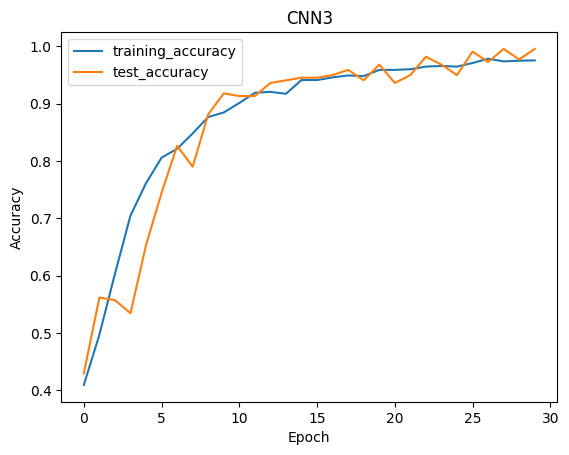

In [ ]:
plt.plot(history3.history['accuracy'], label='training_accuracy')
plt.plot(history3.history['val_accuracy'], label = 'test_accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title("CNN3")

Code forevaluation and analysis

In [ ]:
test_loss, test_acc = model_to_train.evaluate(test_gen)
print("Test Loss: "+str(test_loss))
print("Test Accuracy: "+str(test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.9732 - loss: 0.3489
Test Loss: 0.3697563409805298
Test Accuracy: 0.9680365324020386


In [ ]:
test_loss, test_acc = model_to_train2.evaluate(test_gen)
print("Test Loss: "+str(test_loss))
print("Test Accuracy: "+str(test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.9703 - loss: 0.6098
Test Loss: 0.6214636564254761
Test Accuracy: 0.9634703397750854


In [ ]:
test_loss, test_acc = model_to_train3.evaluate(test_gen)
print("Test Loss: "+str(test_loss))
print("Test Accuracy: "+str(test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.9659 - loss: 0.5376
Test Loss: 0.5348995327949524
Test Accuracy: 0.9680365324020386


Text(0.5, 1.0, 'CNN1')

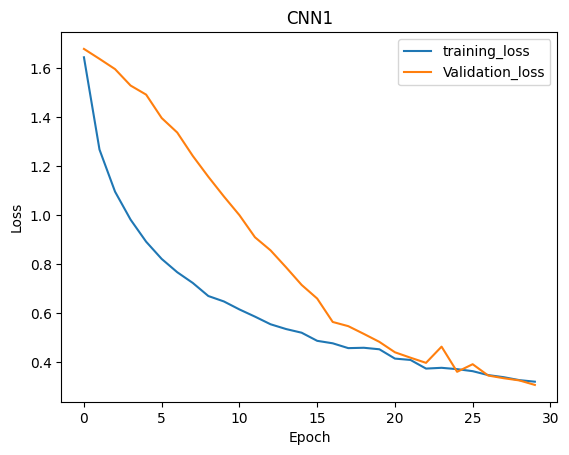

In [ ]:
plt.plot(history1_3.history['loss'], label='training_loss')
plt.plot(history1_3.history['val_loss'], label = 'Validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("CNN1")

Text(0.5, 1.0, 'CNN2')

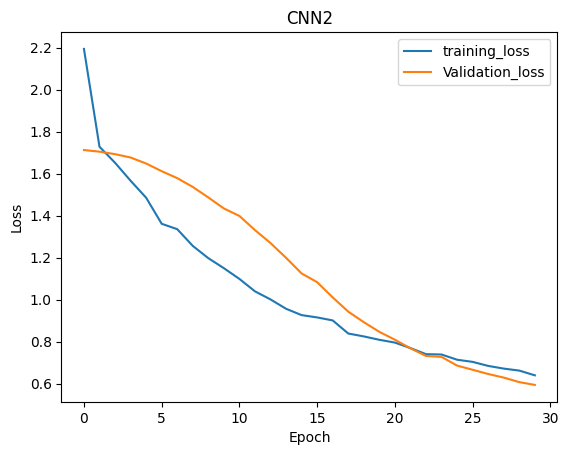

In [ ]:
plt.plot(history2.history['loss'], label='training_loss')
plt.plot(history2.history['val_loss'], label = 'Validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("CNN2")

Text(0.5, 1.0, 'CNN3')

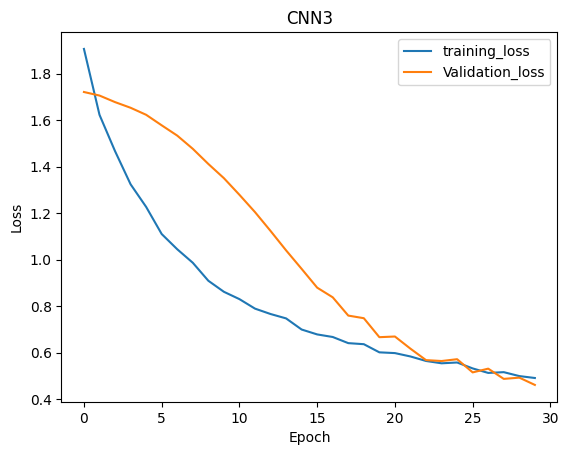

In [ ]:
plt.plot(history3.history['loss'], label='training_loss')
plt.plot(history3.history['val_loss'], label = 'Validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("CNN3")

Cross validation

In [ ]:
import numpy as np
import tensorflow.keras.backend as K
from sklearn.model_selection import KFold

model_funcs = [cnn1_3, cnn2, cnn3]
model_name = ["CNN_1_3", "CNN_2", "CNN_3"]
cv_results = {name: [] for name in model_name}
cv_val_losses = {name: [] for name in model_name}

# Setup Cross-Validation
kfold = KFold(n_splits=3, shuffle=True, random_state=87)
data_generator = ImageDataGenerator(rescale=1./255)

In [ ]:
for train_idx, test_idx in kfold.split(df):

    train_data = df.iloc[train_idx].reset_index(drop=True)
    test_data = df.iloc[test_idx].reset_index(drop=True)

    # Generators
    train_gen = data_generator.flow_from_dataframe(train_data, x_col="paths", y_col="label", target_size=Size, batch_size=64, class_mode="categorical")
    test_gen = data_generator.flow_from_dataframe(test_data, x_col="paths", y_col="label", target_size=Size, batch_size=64, class_mode="categorical", shuffle=False)

    # Model 1
    m1 = cnn1_3()
    h1 = m1.fit(train_gen, validation_data=test_gen, epochs=10, verbose=1)
    cv_results["CNN_1_3"].append(max(h1.history['val_accuracy']))

    # Model 2
    m2 = cnn2()
    h2 = m2.fit(train_gen, validation_data=test_gen, epochs=10, verbose=1)
    cv_results["CNN_2"].append(max(h2.history['val_accuracy']))

    # Model 3
    m3 = cnn3()
    h3 = m3.fit(train_gen, validation_data=test_gen, epochs=10, verbose=1)
    cv_results["CNN_3"].append(max(h3.history['val_accuracy']))


    K.clear_session()

Found 1458 validated image filenames belonging to 3 classes.
Found 730 validated image filenames belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.3953 - loss: 2.0751 - val_accuracy: 0.4425 - val_loss: 1.7136
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.6332 - loss: 1.4439 - val_accuracy: 0.5562 - val_loss: 1.6666
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.7481 - loss: 1.2237 - val_accuracy: 0.7137 - val_loss: 1.6299
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.8092 - loss: 1.0802 - val_accuracy: 0.7082 - val_loss: 1.6045
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8422 - loss: 0.9932 - val_accuracy: 0.8493 - val_loss: 1.5501
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8762 - loss: 0.9160 - val_accuracy: 0.8616 - val_loss: 1.4882
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.8735 - loss: 0.8713 - val_accuracy: 0.8863 - val_loss: 1.4361
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8916 - loss: 0.8452 - val_accuracy: 0.8932 - val_loss:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.4525 - loss: 1.9335 - val_accuracy: 0.7613 - val_loss: 1.6918
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.6937 - loss: 1.3240 - val_accuracy: 0.7819 - val_loss: 1.6487
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7934 - loss: 1.1185 - val_accuracy: 0.8326 - val_loss: 1.6139
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8368 - loss: 1.0049 - val_accuracy: 0.7970 - val_loss: 1.5998
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8926 - loss: 0.9006 - val_accuracy: 0.8121 - val_loss: 1.5642
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8977 - loss: 0.8520 - val_accuracy: 0.8779 - val_loss: 1.4917
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.9207 - loss: 0.7990 - val_accuracy: 0.8450 - val_loss: 1.4666
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9313 - loss: 0.7306 - val_accuracy: 0.8944 - val_loss:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.4188 - loss: 1.9728 - val_accuracy: 0.5158 - val_loss: 1.6944
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.6809 - loss: 1.3773 - val_accuracy: 0.6502 - val_loss: 1.6584
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7699 - loss: 1.2013 - val_accuracy: 0.8313 - val_loss: 1.6078
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.7976 - loss: 1.0730 - val_accuracy: 0.8299 - val_loss: 1.5864
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8494 - loss: 0.9661 - val_accuracy: 0.8148 - val_loss: 1.5577
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8843 - loss: 0.9089 - val_accuracy: 0.8299 - val_loss: 1.4999
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8879 - loss: 0.8445 - val_accuracy: 0.8560 - val_loss: 1.4426
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8941 - loss: 0.8305 - val_accuracy: 0.8971 - val_loss:

/tmp/ipykernel_1078/2892625058.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv_results[name] for name in model_name], labels=model_name)


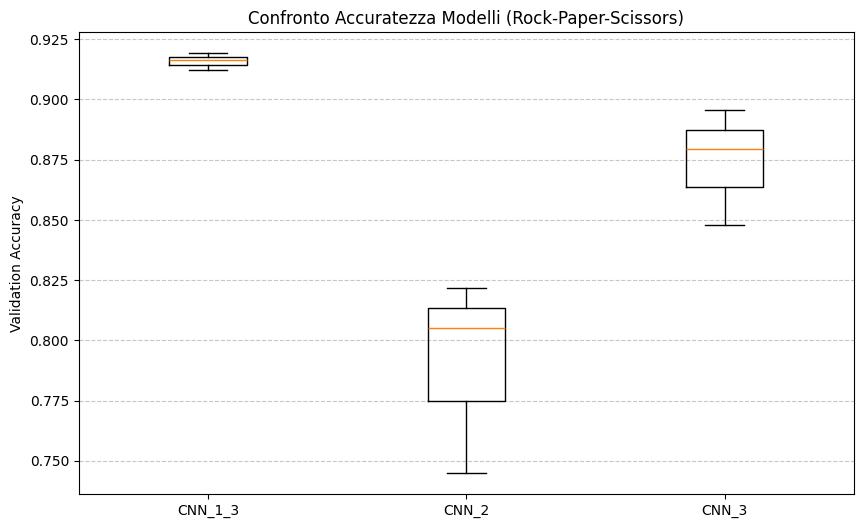


--- PERFORMANCE MEDIE ---
CNN_1_3: 0.9159 (+/- 0.0029)
CNN_2: 0.7907 (+/- 0.0331)
CNN_3: 0.8743 (+/- 0.0198)


In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot([cv_results[name] for name in model_name], labels=model_name)
plt.title('Confronto Accuratezza Modelli (Rock-Paper-Scissors)')
plt.ylabel('Validation Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- PERFORMANCE MEDIE ---")
for nome in model_name:
    print(f"{nome}: {np.mean(cv_results[nome]):.4f} (+/- {np.std(cv_results[nome]):.4f})")